In [ ]:
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn

In [ ]:
#untuk komputasi numerik
import numpy as np

#membantu mempermudah manipulasi data teks
import string

import re

#hilangkan notif karena migrasi dari python
import warnings
warnings.filterwarnings('ignore')

In [ ]:
#import library yang dibutuhkan
import pandas as pd
from tqdm import tqdm, notebook
warnings.filterwarnings('ignore')

pd.pandas.set_option('display.max_columns',None)
pd.pandas.set_option('display.max_rows',None)
pd.pandas.set_option('display.max_colwidth',None)
pd.pandas.set_option('display.width',None)

In [ ]:
df = pd.read_csv('/content/reviews_gojek_databersih-_1_.csv')
df.head(30)

,content,sentiment
0,download lama banget loh,0
1,driver food nya g jelas,0
2,sistem gojek makin kesini makin kacau kasi drivernya aplikasi rasa manusia,0
3,akurat,1
4,mo transfer suruh upgrade gilir upgrade gagal mulu ga jelas banget,0
5,baik update bukan baik malah anehaneh masa tekan me nih aplikasi malah mesan sendiri gojek datang malah akibat aplikasi lucu mesen sendiri sekarang rugi siapa aku kan karna udah potong baik,0
6,baik,1
7,gojek oke,1
8,bagus sekali cepat,1
9,tetap semangat,0


In [ ]:
#Shape of the dataset, and breakdown of the classes
print(f"Input data has {len(df)} rows and {len(df.columns)} columns")
print(f"positive =  {len(df[df['sentiment']==1])} rows")
print(f"negative =  {len(df[df['sentiment']==0])} rows")

Input data has 10000 rows and 2 columns
positive =  6585 rows
negative =  3415 rows


Number of null in label: 0
Number of null in text: 0


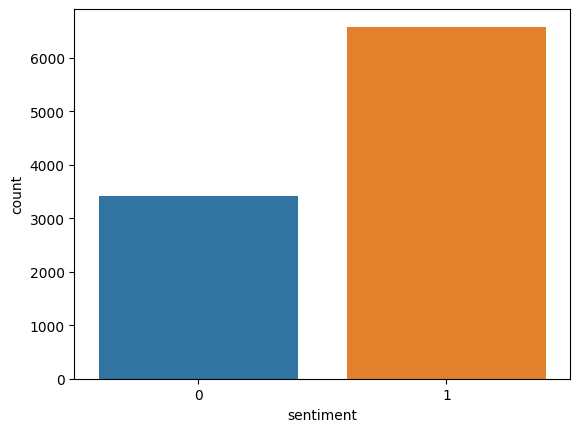

In [ ]:
import seaborn as sns

#Missing values in the dataset
print(f"Number of null in label: { df['sentiment'].isnull().sum() }")
print(f"Number of null in text: { df['content'].isnull().sum() }")
sns.countplot(x='sentiment',data=df);

#Visualizing Word Clouds

In [ ]:
from wordcloud import WordCloud

In [ ]:
df_negative = df[(df['sentiment']==0)]
df_positive = df[(df['sentiment']==1)]

#convert to list
negative_list = df_negative['content'].tolist()
positive_list = df_positive['content'].tolist()

filtered_negative = ("").join(str(negative_list)) #convert the list into a string of spam
filtered_negative = filtered_negative.lower()

filtered_positive = ("").join(str(positive_list)) #convert the list into a string of spam
filtered_positive = filtered_positive.lower()

Word Cloud: Positive Reviews

In [ ]:
import matplotlib.pyplot as plt

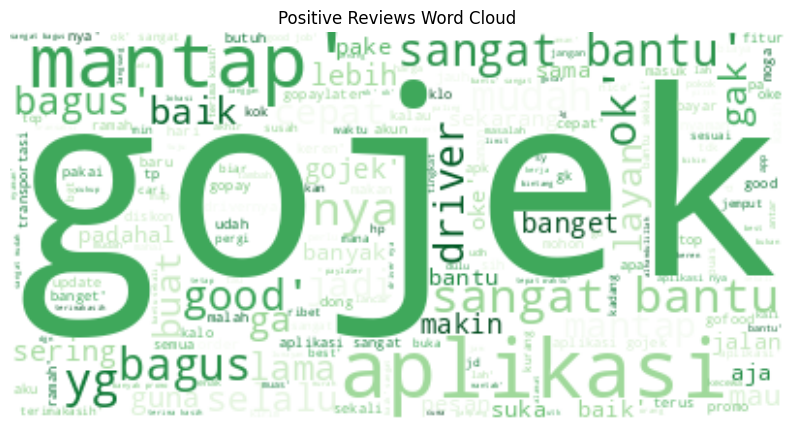

In [ ]:
wordcloud = WordCloud(max_font_size =160, margin = 0, background_color = "white",
                      colormap = "Greens").generate(filtered_positive)
plt.figure(figsize=[10,10])
plt.imshow(wordcloud, interpolation = 'bilinear')
plt.axis ("off")
plt.margins(x=0,y=0)
plt.title("Positive Reviews Word Cloud")
plt.show()

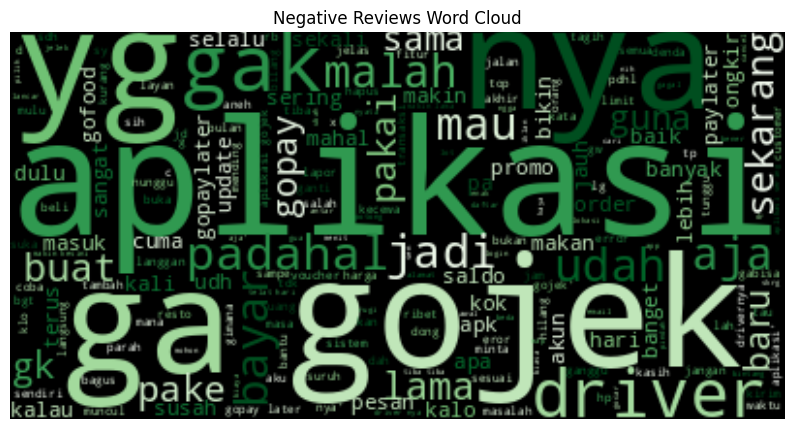

In [ ]:
wordcloud = WordCloud(max_font_size =160, margin = 0, background_color = "black",
                      colormap = "Greens").generate(filtered_negative)
plt.figure(figsize=[10,10])
plt.imshow(wordcloud, interpolation = 'bilinear')
plt.axis ("off")
plt.margins(x=0,y=0)
plt.title("Negative Reviews Word Cloud")
plt.show()

In [ ]:
#Vectorization
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer()
cv.fit(df['content'])
x = cv.transform(df['content'])

y = df['sentiment']

#split Dataset and Build Classifier

In [ ]:
!pip install scikit-learn

In [ ]:
#Split Data
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,y, train_size=0.70)

#Using naive Bayes Algoritm

Alpha=0.01
Accuracy: 0.8493333333333334
Precision: 0.8890046899426784
Recall: 0.877120822622108
F1-score: 0.8830227743271223


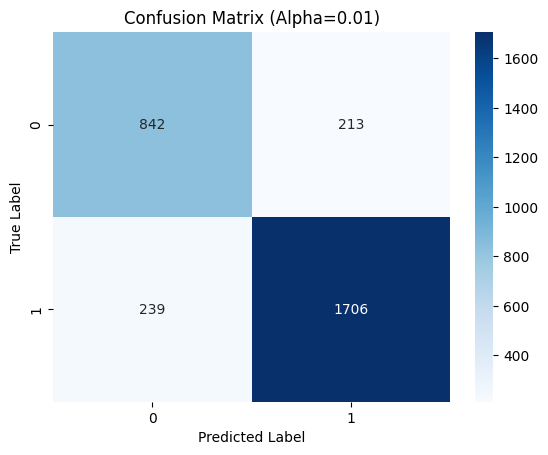

-----------------
Alpha=0.05
Accuracy: 0.8543333333333333
Precision: 0.8918918918918919
Recall: 0.8822622107969151
F1-score: 0.8870509175497544


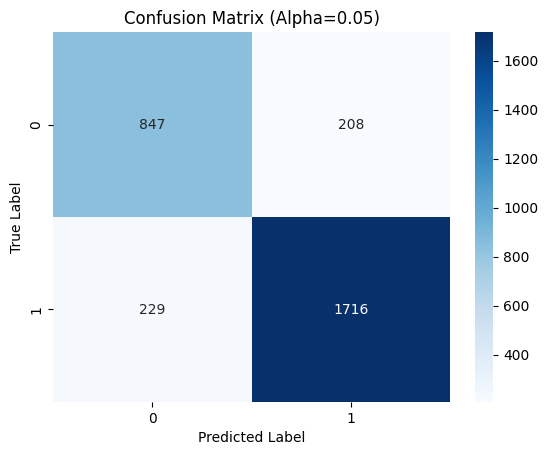

-----------------
Alpha=0.25
Accuracy: 0.8596666666666667
Precision: 0.896875
Recall: 0.8853470437017995
F1-score: 0.8910737386804658


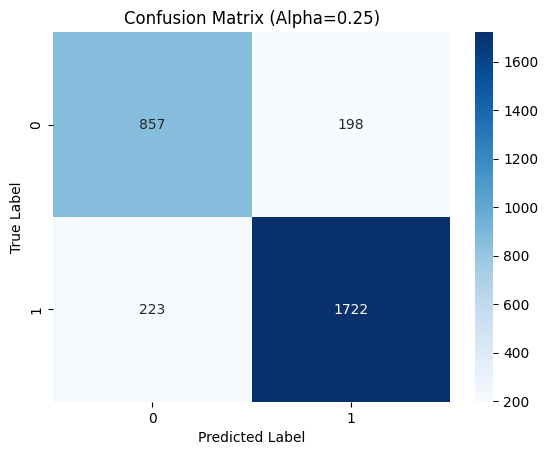

-----------------
Alpha=0.5
Accuracy: 0.86
Precision: 0.8981723237597912
Recall: 0.884318766066838
F1-score: 0.8911917098445598


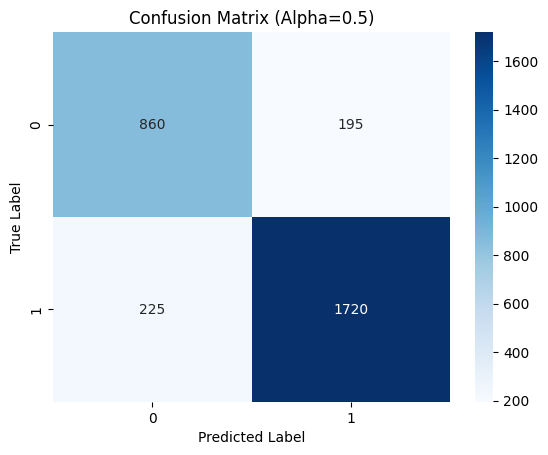

-----------------
Alpha=1
Accuracy: 0.863
Precision: 0.9053911205073996
Recall: 0.880719794344473
F1-score: 0.8928850664581705


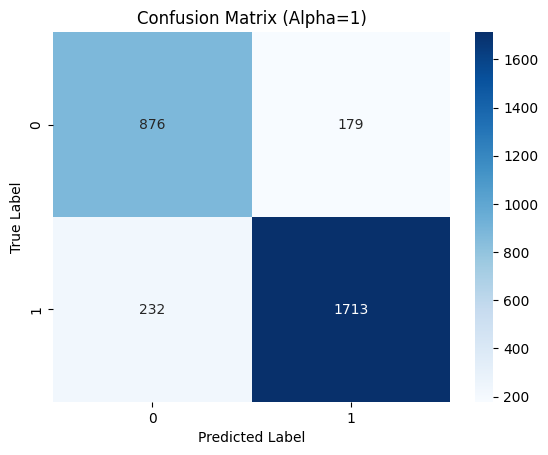

-----------------


In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# List of alpha values to test
alphas = [0.01, 0.05, 0.25, 0.5, 1]

for alpha in alphas:
    nb_classifier = MultinomialNB(alpha=alpha)
    nb_classifier.fit(x_train, y_train)

    # Use the classifier to make predictions on the test set
    y_pred = nb_classifier.predict(x_test)

    # Calculate accuracy, precision, recall, and f1-score for each alpha value
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Calculate confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    print(f'Alpha={alpha}')
    print(f'Accuracy: {accuracy}')
    print(f'Precision: {precision}')
    print(f'Recall: {recall}')
    print(f'F1-score: {f1}')

    # Create a heatmap of the confusion matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix (Alpha={alpha})')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    print('-----------------')